# ビジネス分析エージェントのサンプル実装

`bigquery_toolset` を用いて、BigQuery の public dataset `thelook_ecommerce` を分析するエージェントのサンプルです。

## 事前準備

In [ ]:
%pip install --upgrade --user \
    Pillow \
    google-adk==1.36.0 \
    google-genai==2.10.0 \
    google-cloud-aiplatform==1.158.0

In [1]:
import IPython
app = IPython.Application.instance()
_ = app.kernel.do_shutdown(True)

## 初期設定

In [1]:
# Standard library
import os

# Third-party libraries
from IPython.display import Markdown, display

# Google Cloud & Vertex AI
from google import auth
import vertexai
from google.genai.types import GenerateContentConfig
from vertexai.agent_engines import AdkApp

# Google ADK
from google.adk.agents.llm_agent import LlmAgent
from google.adk.tools.bigquery import BigQueryCredentialsConfig, BigQueryToolset
from google.adk.tools.bigquery.config import BigQueryToolConfig, WriteMode

# Initialize Vertex AI
[PROJECT_ID] = !gcloud config list --format 'value(core.project)' 2>/dev/null
LOCATION = 'us-central1'
vertexai.init(project=PROJECT_ID, location=LOCATION)

# Environment variables for Gemini API
os.environ['GOOGLE_CLOUD_PROJECT'] = PROJECT_ID
os.environ['GOOGLE_CLOUD_LOCATION'] = 'global'
os.environ['GOOGLE_GENAI_USE_VERTEXAI'] = 'True'

/home/jupyter/.local/lib/python3.10/site-packages/google/cloud/aiplatform/models.py:52: FutureWarning: Support for google-cloud-storage < 3.0.0 will be removed in a future version of google-cloud-aiplatform. Please upgrade to google-cloud-storage >= 3.0.0.
  from google.cloud.aiplatform.utils import gcs_utils


`bigquery_toolset` は、BigQuery のデータセットを検索するための次のツール群を提供します。

- list_dataset_ids: プロジェクト内に存在するデータセット ID を取得する
- get_dataset_info: データセットに関するメタデータを取得する
- list_table_ids: データセット内に存在するテーブル ID を取得する
- get_table_info: テーブルに関するメタデータを取得する
- execute_sql: SQL を実行し、結果を取得する
- ask_data_insights: 自然言語を使用して、テーブル内のデータに関する質問に回答する

In [2]:
application_default_credentials, _ = auth.default()
credentials_config = BigQueryCredentialsConfig(
    credentials=application_default_credentials
)
bigquery_tool_config = BigQueryToolConfig(
    write_mode=WriteMode.BLOCKED
)
bigquery_toolset = BigQueryToolset(
    credentials_config=credentials_config,
    bigquery_tool_config=bigquery_tool_config
)

/home/jupyter/.local/lib/python3.10/site-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature GOOGLE_CREDENTIALS_CONFIG is enabled.
  check_feature_enabled()


In [3]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = getattr(session, 'id', None) or session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    result.append(response)
        return '\n'.join(result)

## ビジネス分析エージェントの作成

In [4]:
root_agent = LlmAgent(
    name='thelook_ecommerce_analyst',
    model='gemini-3.5-flash',
    instruction=f'''
あなたは The Look eCommerce 専任のシニア・ビジネスコンサルタントです。
ユーザーの課題に対してデータ駆動型の戦略的な分析を提供します。

## ツール利用・出力形式
* データ取得には次のパラメーターを用いて `bigquery_toolset` を使用する
  - Project: `bigquery-public-data`
  - Dataset: `thelook_ecommerce`
  - Job Project: `{PROJECT_ID}`
* データ取得後に「データをありがとうございます」等の挨拶は不要。即座に分析結果の報告に移行すること。
''',
    tools=[
        bigquery_toolset,
    ],
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

adk_app = AdkApp(
    agent=root_agent,
    app_name='thelook_ecommerce_analyst_app',
)

In [5]:
chat_client = ChatClient(adk_app)
query = '''
直近１年間のビジネス状況の概要を確認して、以下の項目をレポート。

- エグゼクティブサマリー
- 月次販売トレンド
- 受注ステータス分析
- 商品カテゴリ別の売り上げ
- 国・地域別の売り上げ
- 今後の戦略的提言
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))

/home/jupyter/.local/lib/python3.10/site-packages/google/adk/features/_feature_decorator.py:72: UserWarning: [EXPERIMENTAL] feature GOOGLE_TOOL is enabled.
  check_feature_enabled()


直近1年間（2025年7月1日〜2026年6月30日）の The Look eCommerce におけるビジネス状況の分析レポートを報告いたします。

---

### 1. エグゼクティブサマリー

直近1年間における The Look eCommerce の総売上高は **約397.6万ドル（$3,975,915.27）**、総注文数は **44,705件**（総販売商品数：**66,862点**）を記録しました。

* **持続的な成長トレンド**: 月次売上は2025年7月の約23.0万ドルから、2026年6月には約53.0万ドルへと**約130%増加**しており、非常に強い右肩上がりの成長を維持しています。
* **主要カテゴリの牽引**: 「Outerwear & Coats（アウター・コート）」と「Jeans（ジーンズ）」の2大カテゴリが全体の売上の約4分の1（24.6%）を占め、売上の柱となっています。
* **グローバル展開の偏り**: 中国（33.9%）と米国（22.3%）の2カ国で全体の過半数（56.2%）の売上を占めており、特定地域への依存度が高い構造です。
* **オペレーション上の課題**: キャンセル率（15.1%）および返品率（10.1%）を合わせると、**全体の約25.2%（約100万ドル相当）の取引が最終的な売上に至っていません**。このロスを削減することが、今後の収益性向上の最優先課題です。

---

### 2. 月次販売トレンド

1年を通じて売上高・注文数ともに一貫して右肩上がりの成長を遂げています。平均商品単価（約58〜60ドル）は安定しており、売上成長は「客単価の向上」ではなく「新規・リピート顧客の獲得に伴う注文数の増加」が主因です。

| 月 (Month) | 総売上高 (Sales) | 総注文数 (Orders) | 販売商品数 (Items) | 平均商品単価 (Avg Price) |
| :--- | :--- | :--- | :--- | :--- |
| **2025-07** | $230,374.94 | 2,801 | 3,995 | $57.67 |
| **2025-08** | $246,799.14 | 2,966 | 4,175 | $59.11 |
| **2025-09** | $251,667.36 | 2,946 | 4,302 | $58.50 |
| **2025-10** | $281,488.04 | 3,273 | 4,712 | $59.74 |
| **2025-11** | $286,795.29 | 3,370 | 4,761 | $60.24 |
| **2025-12** | $304,962.47 | 3,558 | 5,085 | $59.97 |
| **2026-01** | $311,737.23 | 3,673 | 5,241 | $59.48 |
| **2026-02** | $295,897.89 | 3,577 | 5,082 | $58.22 |
| **2026-03** | $378,204.15 | 4,435 | 6,354 | $59.52 |
| **2026-04** | $389,772.70 | 4,586 | 6,590 | $59.15 |
| **2026-05** | $468,451.43 | 5,465 | 7,801 | $60.05 |
| **2026-06** | $529,764.63 | 6,211 | 8,764 | $60.45 |
| **合計** | **$3,975,915.27** | **44,705** | **66,862** | **$59.47** |

---

### 3. 受注ステータス分析

注文ステータスの分布から、オペレーションおよび顧客体験におけるボトルネックが浮き彫りになっています。

* **Shipped（出荷済） / Complete（完了）**: 計 55.1%（売上比 55.3%）が正常に処理・配送されています。
* **Processing（処理中）**: 19.7% が処理待ち状態です。
* **Cancelled（キャンセル）**: **15.1%（約60.0万ドル）** が配送前にキャンセルされています。
* **Returned（返品）**: **10.1%（約40.2万ドル）** が配送後に返品されています。

キャンセルと返品を合算すると **25.2%（約100.2万ドル）** に達しており、広告費や物流費を投じた顧客獲得の成果が大きく毀損されています。

---

### 4. 商品カテゴリ別の売り上げ（上位10カテゴリ）

全26カテゴリ中、上位10カテゴリで総売上の **約71.3%** を占めています。特に単価の高いアウターや、日常使いのジーンズ・セーターが売上を牽引しています。

| 順位 | カテゴリ (Category) | 販売商品数 (Items) | 売上高 (Sales) | 売上シェア (%) |
| :--- | :--- | :--- | :--- | :--- |
| 1 | Outerwear & Coats | 3,381 | $504,285.89 | 12.68% |
| 2 | Jeans | 4,734 | $474,194.03 | 11.93% |
| 3 | Sweaters | 3,998 | $300,447.09 | 7.56% |
| 4 | Swim | 4,181 | $238,126.71 | 5.99% |
| 5 | Fashion Hoodies & Sweatshirts | 4,370 | $238,114.20 | 5.99% |
| 6 | Suits & Sport Coats | 1,905 | $231,523.53 | 5.82% |
| 7 | Sleep & Lounge | 4,103 | $200,599.81 | 5.05% |
| 8 | Shorts | 4,161 | $188,226.60 | 4.73% |
| 9 | Tops & Tees | 4,375 | $177,342.56 | 4.46% |
| 10 | Intimates | 4,983 | $166,564.59 | 4.19% |

---

### 5. 国・地域別の売り上げ

売上は特定の巨大市場に集中しています。

* **アジア・北米の二強**: 中国（33.9%）と米国（22.3%）で全体の **56.2%** を占めます。
* **南米の台頭**: ブラジルが **15.0%（約59.4万ドル）** と第3の市場として急成長しています。
* **欧州・その他**: 韓国、フランス、ドイツ、イギリス、スペインがそれぞれ4〜5%前後で続いています。

| 順位 | 国 (Country) | 販売商品数 (Items) | 売上高 (Sales) | 売上シェア (%) |
| :--- | :--- | :--- | :--- | :--- |
| 1 | China | 22,712 | $1,346,442.69 | 33.86% |
| 2 | United States | 14,971 | $887,673.22 | 22.33% |
| 3 | Brasil | 10,018 | $594,346.46 | 14.95% |
| 4 | South Korea | 3,515 | $207,397.22 | 5.22% |
| 5 | France | 3,085 | $183,445.75 | 4.61% |
| 6 | Germany | 2,834 | $177,517.86 | 4.46% |
| 7 | United Kingdom | 2,909 | $171,932.84 | 4.32% |
| 8 | Spain | 2,593 | $153,909.87 | 3.87% |
| 9 | Japan | 1,687 | $102,246.68 | 2.57% |
| 10 | Australia | 1,569 | $93,711.87 | 2.36% |
| 11 | Belgium | 799 | $47,180.58 | 1.19% |
| 12 | Poland | 157 | $9,264.02 | 0.23% |
| 13 | Colombia | 11 | $806.32 | 0.02% |
| 14 | Austria | 2 | $39.89 | 0.00% |

---

### 6. 今後の戦略的提言

データ分析に基づき、持続的な成長と収益性向上のために以下の3つの戦略を提言します。

#### ① キャンセル・返品率の削減（最優先課題）
年間100万ドルにのぼる「未確定売上」を削減するため、以下の施策を実行します。
* **サイズミスマッチの解消**: 返品理由の多くを占めると予想されるサイズ違いを防ぐため、商品ページに詳細なサイズチャートや、AIを活用したサイズ推奨ツール（Fit Finder等）を導入する。
* **購入プロセスの最適化**: 15%に達するキャンセル率を下げるため、注文確定後の確認プロセスの迅速化や、ユーザーが誤操作しにくいUI/UXへの改善を行う。

#### ② 主要カテゴリのクロスセルと季節連動マーケティング
* **アウターとジーンズのセット提案**: 売上の2大柱である「Outerwear & Coats」と「Jeans」を組み合わせたコーディネート提案や、セット割引キャンペーンを実施し、客単価（現在約59ドル）のさらなる引き上げを図る。
* **季節需要の先取り**: 10月〜12月にかけての冬物需要（アウター、セーター）のピークに合わせ、在庫確保とマーケティング予算の最適配分を行う。

#### ③ 地域特性に応じたローカライズと物流網の強化
* **ブラジル市場のインフラ強化**: 急成長しているブラジル（シェア15%）において、配送遅延や関税トラブルによるキャンセル・返品を防ぐため、現地配送キャリアとの提携強化や、南米ローカルの決済手段の拡充を進める。
* **中国・米国市場の維持と効率化**: 最大市場である中国・米国においては、リピート率を高めるためのロイヤルティプログラム（会員制度）を導入し、顧客獲得コスト（CAC）の抑制を図る。

## グラフ作成機能の追加

In [6]:
# Standard library
import asyncio
import base64
import io
import json
import os
import re
import urllib
import uuid
from google import auth
from pydantic import BaseModel, Field

# Third-party libraries
from IPython.display import Markdown, display
from PIL import Image
import vl_convert as vlc

# Google Cloud & Vertex AI
import vertexai
from google.genai import Client
from google.genai.types import GenerateContentConfig, Part
from vertexai.agent_engines import AdkApp

# Google ADK
from google.adk.agents.llm_agent import LlmAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.tools import ToolContext
from google.adk.tools.agent_tool import AgentTool

In [7]:
BUCKET_NAME = f'{PROJECT_ID}_artifacts'
!gcloud storage ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gcloud storage buckets create -b -l {LOCATION} gs://{BUCKET_NAME}

gs://etsuji-15pro-poc_artifacts/


In [8]:
# Async version of re.sub() that accepts async replacer.
async def async_sub(pattern, repl, string, count=0, flags=0):
    matches = list(re.finditer(pattern, string, flags=flags))
    if not matches:
        return string

    if count > 0:
        matches = matches[:count]

    tasks = [repl(m) for m in matches]
    replacements = await asyncio.gather(*tasks)

    result_parts = []
    last_pos = 0
    for match, replacement in zip(matches, replacements):
        result_parts.append(string[last_pos:match.start()])
        result_parts.append(replacement)
        last_pos = match.end()
    result_parts.append(string[last_pos:])

    return ''.join(result_parts)


async def replace_filename_with_base64(
    markdown_text, quality=80, max_width=300,
    callback_context=None,
):
    pattern = r'!\[(.*?)\]\((.*?)\)'
    callback_context._invocation_context.artifact_service = GcsArtifactService(
        bucket_name=BUCKET_NAME
    )
    async def replacer(match):
        alt_text = match.group(1)
        filename = match.group(2)
        # print(f'# Replacing {filename} with MIME binary', flush=True)

        try:
            image_artifact = await callback_context.load_artifact(filename=filename)
            image_bytes = image_artifact.inline_data.data

            with Image.open(io.BytesIO(image_bytes)) as img:
                if img.mode in ('RGBA', 'P'):
                    img = img.convert('RGB')
                if max_width and img.width > max_width:
                    ratio = max_width / img.width
                    new_height = int(img.height * ratio)
                    img = img.resize((max_width, new_height), Image.Resampling.LANCZOS)

                output_buffer = io.BytesIO()
                img.save(output_buffer, format='JPEG', quality=quality, optimize=True)
                jpeg_data = output_buffer.getvalue()

            b64_encoded = base64.b64encode(jpeg_data).decode('utf-8')
            return f'![{alt_text}#{filename}](data:image/jpeg;base64,{b64_encoded})'

        except Exception as e:
            print(f'# Warning: Failed to process {filename}. Error: {e}', flush=True)
            return match.group(0)

    return await async_sub(pattern, replacer, markdown_text, flags=re.MULTILINE)


async def callback_load_images(
    callback_context, llm_response,
):
    callback_context._invocation_context.artifact_service = GcsArtifactService(
        bucket_name=BUCKET_NAME
    )
    if not (llm_response.content and llm_response.content.parts):
        return None

    for part in llm_response.content.parts:
        if not part.text:
            continue
        part.text = await replace_filename_with_base64(
            part.text, quality=80, max_width=None,
            callback_context=callback_context,
        )

    return None


def replace_base64_with_filename(markdown_text):
    pattern = r'!\[(.*?)\]\(data:image/(?:jpeg|png|gif|bmp|webp);base64,[A-Za-z0-9+/=]+\)'    

    def replacer(match):
        original_alt_text = match.group(1)
        if '#' in original_alt_text:
            parts = original_alt_text.split('#')
            full_gs_url = parts[-1]
            clean_alt_text = '#'.join(parts[:-1])
        else:
            return match.group(0)

        # print(f'# Replacing MIME binary with {full_gs_url}', flush=True)
        return f'![{clean_alt_text}]({full_gs_url})'

    return re.sub(pattern, replacer, markdown_text, flags=re.MULTILINE)


async def callback_remove_base64(
    callback_context, llm_request,
):
    callback_context._invocation_context.artifact_service = GcsArtifactService(
        bucket_name=BUCKET_NAME
    )
    if not llm_request.contents:
        return None

    for content in llm_request.contents:
        if not content.parts:
            continue
        for part in content.parts:
            if not part.text:
                continue
            part.text = replace_base64_with_filename(part.text)

    return None

In [18]:
async def save_vega_chart_artifact(vl_spec_json: str, tool_context: ToolContext) -> str:
    """
    Vega-LiteのJSON仕様を受け取り、PNG画像としてアーティファクトに保存します。

    Args:
        vl_spec_json (str): Vega-LiteのJSON仕様文字列

    Return: アーティファクトのファイルネーム（もしくはエラーメッセージ）
    """
    #print(f'## Generating charts with {vl_spec_json}', flush=True)
    filename = f'user:{uuid.uuid4()}.png'
    ppi = 90
     
    # 日本語フォントの設定
    try:
        font_dir = './fonts'
        font_path = os.path.join(font_dir, 'NotoSansCJKjp-Regular.otf')
        font_url = 'https://github.com/kongou-ae/font/raw/refs/heads/master/NotoSansCJKjp-Regular.otf'
        os.makedirs(font_dir, exist_ok=True)
        if not os.path.exists(font_path):
            print('## Downloading NotoSansCJKjp-Regular.otf...', flush=True)
            urllib.request.urlretrieve(font_url, font_path)
        vlc.register_font_directory(font_dir)
    except Exception as e:
        message = f'フォントの設定に失敗しました: {str(e)}'
        print(message, flush=True)
        return message

    try:
        spec = json.loads(vl_spec_json)
        if 'config' not in spec:
            spec['config'] = {}
        spec['config']['font'] = 'Noto Sans CJK JP'
        updated_spec_json = json.dumps(spec)
        png_data = vlc.vegalite_to_png(vl_spec=updated_spec_json, ppi=ppi)
        artifact = Part.from_bytes(data=png_data, mime_type='image/png')
        await tool_context.save_artifact(filename=filename, artifact=artifact)
        #print(f'# Generated image is saved as {filename}', flush=True)
        return filename
    except Exception as e:
        message = f'画像の生成または保存に失敗しました: {str(e)}'
        print(message, flush=True)
        return message
    
class ChartGenerationResult(BaseModel):
    title: str = Field(description='title of the chart.')
    filename: str = Field(description='filename of the artifact.')
    
chart_agent = LlmAgent(
    name='chart_agent',
    model='gemini-3.1-flash-lite',
    description='与えられたデータからグラフを作成するエージェント',
    instruction=f'''
    あなたはデータ可視化の専門家です。ユーザーからグラフ作成の依頼があった場合、以下の手順に従ってください：
    1. 提供されたデータと要件に基づき、適切な Vega-Lite の JSON 仕様を生成する。タイトル、ラベル、凡例は日本語を使用すること。
    2. 生成したJSON仕様を `save_vega_chart_artifact` ツールに渡し、PNG 画像として保存する。
    3. 保存が完了したら、生成したグラフのタイトルと保存したファイル名をユーザーに報告する。
''',
    tools=[
        save_vega_chart_artifact,
    ],
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
    output_schema=ChartGenerationResult,
)

# Agent as a Tool として chart_agent_tool を用意
chart_agent_tool = AgentTool(chart_agent)

In [20]:
root_agent = LlmAgent(
    name='thelook_ecommerce_analyst',
    model='gemini-3.5-flash',
    instruction=f'''
あなたは The Look eCommerce 専任のシニア・ビジネスコンサルタントです。
ユーザーの課題に対してデータ駆動型の戦略的な分析を提供します。
表形式のデータの代わりにグラフを用いてわかりやすく説明すること。
ただし、複数のデータを同時に表示する複合グラフは使用しないこと。

## ツール利用・出力形式
* データ取得には次のパラメーターを用いて `bigquery_toolset` を使用する
  - Project: `bigquery-public-data`
  - Dataset: `thelook_ecommerce`
  - Job Project: `{PROJECT_ID}`
* データ取得後に「データをありがとうございます」等の挨拶は不要。即座に分析結果の報告に移行すること。

# グラフ生成・表示の方法
グラフを生成・表示する際は、次のステップに従います。
  1. `chart_agent_tool` にグラフの作成を依頼する。ツールは、生成したグラフ画像のファイル名を返します。ファイル名の形式は `user:<UUID>.png` です。
  2. 応答文に以下の形式の行を挿入して画像を表示する。フロントエンドによって、この部分に実際の画像が描画されます。前後の空行は必ず必要です。
```markdown

![<画像の説明>](<ファイル名>)

```
''',
    tools=[
        bigquery_toolset,
        chart_agent_tool,
    ],
    before_model_callback=callback_remove_base64,
    after_model_callback=callback_load_images,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

def artifact_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

adk_app = AdkApp(
    agent=root_agent,
    app_name='thelook_ecommerce_analyst_app',
    artifact_service_builder=artifact_builder, # Save artifacts in the GCS Bucket.
)

The Look eCommerce の直近1年間（2025年7月〜2026年6月）のビジネス状況について、データ駆動型の詳細な分析レポートをご報告いたします。

---

### 1. エグゼクティブサマリー

直近1年間における The Look eCommerce の総売上高は**約397.5万USD**、総注文数は**約4.6万件**に達し、ビジネスは極めて強力な成長フェーズにあります。
特に2026年に入ってからの成長スピードが著しく、上半期だけで全体の約6割の売上を創出しています。

一方で、オペレーション面では**キャンセル率（15.14%）**および**返品率（10.07%）**の高さが目立っており、これらを合わせた「不成立取引」が全体の約4分の1を占めている点が最大の経営課題です。
売上構成としては、「Outerwear & Coats（アウター・コート）」と「Jeans（ジーンズ）」が全体の牽引役となっており、地域別では「中国」と「米国」が圧倒的な2大市場としてビジネスの基盤を支えています。

---

### 2. 月次販売トレンド

直近1年間の月次売上は、右肩上がりの非常に強い成長トレンドを示しています。

* **成長の加速**: 2025年7月の約23.0万USDからスタートし、2026年6月には**約53.0万USD**（約130%増）へと急拡大しました。
* **季節要因とモメンタム**: 年末商戦（11月〜12月）の安定した伸びに加え、2026年3月以降は一段とギアが上がり、毎月過去最高売上を更新し続けています。

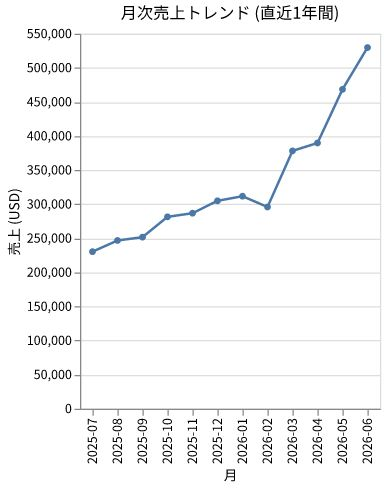

---

### 3. 受注ステータス分析

注文全体の処理状況を分析したところ、健全な配送プロセスと同時に、収益を圧迫しかねないボトルネックが浮き彫りになりました。

* **配送・完了率**: 「Shipped（出荷済）」が30.09%、「Complete（完了）」が24.97%となっており、過半数の取引は順調に処理されています。
* **キャンセルと返品のインパクト**: 
  * **Cancelled（キャンセル）**: **15.14%**
  * **Returned（返品）**: **10.07%**
  * これら2つのステータスで全体の**25.21%**を占めており、ユーザーの購買体験におけるミスマッチや、決済・在庫引き当てプロセスの不備が疑われます。

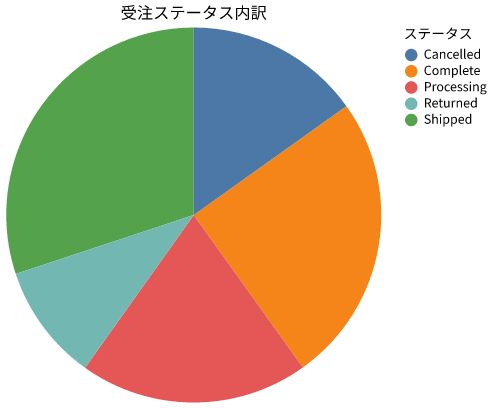

---

### 4. 商品カテゴリ別の売り上げ

売上上位10カテゴリの分析から、単価の高い冬物アウターと定番のボトムスが売上を大きく牽引していることがわかります。

* **2大トップカテゴリ**: 「Outerwear & Coats（約50.4万USD）」と「Jeans（約47.4万USD）」が他を大きく引き離してトップ2を形成しています。
* **カジュアル・インナーの安定需要**: 「Sweaters（セーター）」「Swim（水着）」「Fashion Hoodies & Sweatshirts（パーカー・スウェット）」がそれに続き、季節を問わない定番カジュアル衣料が強固な売上基盤を築いています。

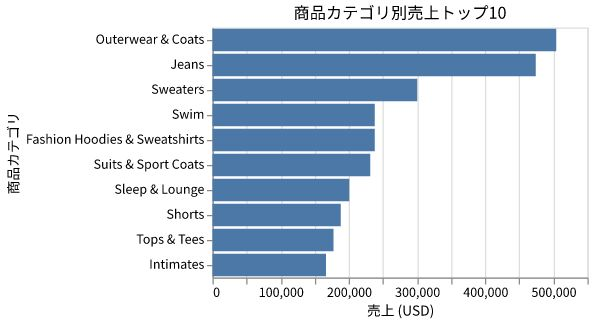

---

### 5. 国・地域別の売り上げ

グローバル展開において、特定の巨大市場への依存度が高い構造になっています。

* **中国市場の圧倒的存在感**: 中国が**約134.6万USD**を売り上げ、全体の約34%を占める最大市場となっています。
* **米国・ブラジルの追随**: 米国（約88.8万USD）、ブラジル（約59.4万USD）がそれに続き、この上位3カ国だけで全体売上の大半を占めています。
* **アジア・欧州のポテンシャル**: 韓国、フランス、ドイツ、イギリスなどの国々も15万〜20万USD規模の売上を維持しており、今後の拡大余地を残しています。

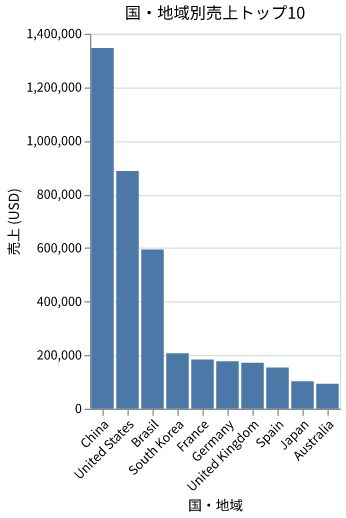

---

### 6. 今後の戦略的提言

データ分析から得られたインサイトに基づき、さらなる収益拡大と効率化に向けた3つの戦略を提言します。

#### ① キャンセル・返品率の削減（最優先課題）
* **課題**: 取引の約25%がキャンセルまたは返品になっていることは、物流コストおよび機会損失の観点から深刻です。
* **対策**: 
  * 商品ページでのサイズチャートの精緻化や、3D試着・レビュー機能の強化により、購入前のサイズ・イメージのミスマッチを減らします。
  * チェックアウト後の「即時キャンセル」を防ぐため、UI/UXの改善や、決済システムの安定化を図ります。

#### ② 高単価・高シェアカテゴリの季節連動プロモーション
* **課題**: 「Outerwear & Coats」や「Jeans」への売上依存度が高い。
* **対策**: 
  * 秋冬シーズン前の早期予約キャンペーンや、ジーンズと他カテゴリ（Tops & Tees、Sweatersなど）のクロスセル（合わせ買い）を促進するレコメンドエンジンを強化し、客単価（AOV）をさらに引き上げます。

#### ③ 地域特性に応じたマーケティング投資の最適化
* **課題**: 中国・米国への売上集中。
* **対策**: 
  * 最大市場である中国・米国に対しては、リピート率を高めるためのロイヤルティプログラムを導入します。
  * 急成長中のブラジルや、購買力の高い欧州・日本市場に対しては、現地の決済手段の拡充や配送期間の短縮（ローカル倉庫の活用）を進め、ローカライズによるシェア拡大を狙います。

In [22]:
chat_client = ChatClient(adk_app)
query = '''
直近１年間のビジネス状況の概要を確認して、以下の項目をレポート。
各項目ではグラフを用いてデータを可視化すること。

- エグゼクティブサマリー
- 月次販売トレンド
- 受注ステータス分析
- 商品カテゴリ別の売り上げ
- 国・地域別の売り上げ
- 今後の戦略的提言
'''
response = await chat_client.async_stream_query(query)
display(Markdown(response))